In [1]:
# ============================================================
# CELL 1 — IMPORTS & PATH CONFIGURATION
# ============================================================

import pandas as pd
import geopandas as gpd
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Paths
BASE_PATH = r"C:\Users\User\Desktop\Data Analysis\Nairobi Public Health Facility Access Analysis"
RAW_PATH  = os.path.join(BASE_PATH, "data", "raw")

# Confirm
print("BASE PATH EXISTS:", os.path.exists(BASE_PATH))
print("RAW  PATH EXISTS:", os.path.exists(RAW_PATH))
print("\nFiles in raw:")
for f in os.listdir(RAW_PATH):
    print(f"  {f}")

BASE PATH EXISTS: True
RAW  PATH EXISTS: True

Files in raw:
  2019-Kenya-population-and-Housing-Census-Population-households-density-by-sub-county.xlsx
  kenya-health-facilities-2017_08_02.xlsx
  ken_admin2.geojson


In [2]:
# CELL 2 — POPULATION DATA INITIAL INSPECTION

pop_raw = pd.read_excel(
    os.path.join(RAW_PATH, "2019-Kenya-population-and-Housing-Census-Population-households-density-by-sub-county.xlsx")
)

print("Shape:", pop_raw.shape)
print("\nColumn names:")
for col in pop_raw.columns:
    print(f"  '{col}'")
print("\nFirst 10 rows:")
pop_raw.head(10)

Shape: (402, 11)

Column names:
  'Population by Sex, Households, Land Area, Density by Sub-county'
  'Unnamed: 1'
  'Unnamed: 2'
  'Unnamed: 3'
  'Unnamed: 4'
  'Unnamed: 5'
  'Unnamed: 6'
  'Unnamed: 7'
  'Unnamed: 8'
  'Unnamed: 9'
  'Unnamed: 10'

First 10 rows:


,"Population by Sex, Households, Land Area, Density by Sub-county",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sub County,NaN,Sex*,NaN,NaN,Households,NaN,Land Area,Density,NaN,*please refer to the Metadata sheet
2,NaN,Total,Male,Female,Total,Conventional,Group quarters,Sq. Km,Persons Per Sq. Km,NaN,NaN
3,KENYA,47564296,23548056,24014716,12143913,12043016,100897,580895.36,81.88,NaN,NaN
4,MOMBASA,1208333,610257,598046,378422,376295,2127,219.90,5495.01,NaN,NaN
5,CHANGAMWE,131882,68761,63121,46614,46439,175,17.69,7457.01,NaN,NaN
6,JOMVU,163415,83002,80410,53472,53214,258,36.87,4432.18,NaN,NaN
7,KISAUNI,291930,146748,145176,88202,88159,43,87.72,3328.11,NaN,NaN
8,LIKONI,250358,126962,123392,81191,80002,1189,40.46,6187.24,NaN,NaN
9,MVITA,154171,75565,78601,38995,38710,285,14.62,10543.10,NaN,NaN


In [3]:
# CELL 3 — RELOAD POPULATION FILE WITH CORRECT HEADERS

pop_raw = pd.read_excel(
    os.path.join(RAW_PATH, "2019-Kenya-population-and-Housing-Census-Population-households-density-by-sub-county.xlsx"),
    header=None,
    skiprows=3
)

# Manually assign clean column names based on what we saw
pop_raw.columns = [
    'sub_county', 'total_pop', 'male_pop', 'female_pop',
    'total_households', 'conventional_households', 'group_quarters',
    'area_sqkm', 'density_per_sqkm', 'unnamed_9', 'unnamed_10'
]

print("Shape:", pop_raw.shape)
print("\nFirst 10 rows:")
print(pop_raw.head(10).to_string())


Shape: (400, 11)

First 10 rows:
          sub_county total_pop  male_pop female_pop total_households conventional_households  group_quarters area_sqkm    density_per_sqkm  unnamed_9  unnamed_10
0                NaN     Total      Male     Female            Total            Conventional  Group quarters    Sq. Km  Persons Per Sq. Km        NaN         NaN
1              KENYA  47564296  23548056   24014716         12143913                12043016          100897 580895.36               81.88        NaN         NaN
2            MOMBASA   1208333    610257     598046           378422                  376295            2127    219.90             5495.01        NaN         NaN
3          CHANGAMWE    131882     68761      63121            46614                   46439             175     17.69             7457.01        NaN         NaN
4              JOMVU    163415     83002      80410            53472                   53214             258     36.87             4432.18        NaN        

In [4]:
# CELL 4 — DROP LEFTOVER HEADER ROW AND UNNECESSARY COLUMNS

pop_raw = pop_raw.drop(index=0).reset_index(drop=True)

# Drop columns we don't need
pop_raw = pop_raw.drop(columns=['unnamed_9', 'unnamed_10', 'male_pop', 'female_pop',
                                 'conventional_households', 'group_quarters'])

# Convert numeric columns from object to correct types
numeric_cols = ['total_pop', 'total_households', 'area_sqkm', 'density_per_sqkm']
for col in numeric_cols:
    pop_raw[col] = pd.to_numeric(pop_raw[col], errors='coerce')

print("Shape:", pop_raw.shape)
print("\nData types:")
print(pop_raw.dtypes)
print("\nFirst 10 rows:")
print(pop_raw.head(10).to_string())


Shape: (399, 5)

Data types:
sub_county              str
total_pop           float64
total_households    float64
area_sqkm           float64
density_per_sqkm    float64
dtype: object

First 10 rows:
          sub_county   total_pop  total_households  area_sqkm  density_per_sqkm
0              KENYA 47564296.00       12143913.00  580895.36             81.88
1            MOMBASA  1208333.00         378422.00     219.90           5495.01
2          CHANGAMWE   131882.00          46614.00      17.69           7457.01
3              JOMVU   163415.00          53472.00      36.87           4432.18
4            KISAUNI   291930.00          88202.00      87.72           3328.11
5             LIKONI   250358.00          81191.00      40.46           6187.24
6              MVITA   154171.00          38995.00      14.62          10543.10
7              NYALI   216577.00          69948.00      22.54           9609.52
8              KWALE   866820.00         173176.00    8253.66            105.02
9

In [5]:
# CELL 5 — LOCATE NAIROBI IN THE DATASET

# Find the row index where NAIROBI appears
nairobi_index = pop_raw[pop_raw['sub_county'] == 'NAIROBI'].index

print("Nairobi found at index:", nairobi_index.tolist())
print("\nRows around Nairobi:")
print(pop_raw.iloc[nairobi_index[0]-1 : nairobi_index[0]+20].to_string())

Nairobi found at index: []

Rows around Nairobi:


IndexError: index 0 is out of bounds for axis 0 with size 0

In [6]:
# CELL 5 FIX — FIND NAIROBI WITH FLEXIBLE SEARCH

# Check all unique sub_county values that contain 'nairobi' case-insensitive
matches = pop_raw[pop_raw['sub_county'].str.contains('nairobi', case=False, na=False)]
print("Matches containing 'nairobi':")
print(matches.to_string())

# Also print all county-level rows to understand file structure
print("\nAll rows where total_pop > 1000000:")
print(pop_raw[pop_raw['total_pop'] > 1000000].to_string())

Matches containing 'nairobi':
           sub_county  total_pop  total_households  area_sqkm  density_per_sqkm
386      NAIROBI CITY 4397073.00        1506888.00     703.87           6247.00

All rows where total_pop > 1000000:
           sub_county   total_pop  total_households  area_sqkm  density_per_sqkm
0               KENYA 47564296.00       12143913.00  580895.36             81.88
1             MOMBASA  1208333.00         378422.00     219.90           5495.01
14             KILIFI  1453787.00         298472.00   12553.27            115.81
73               MERU  1545714.00         426360.00    7013.95            220.38
101             KITUI  1136187.00         262942.00   30429.61             37.34
120          MACHAKOS  1421932.00         402466.00    6037.27            235.53
167          MURANG'A  1056640.00         318105.00    2522.77            418.84
177            KIAMBU  2417735.00         795241.00    2538.70            952.35
215       UASIN GISHU  1163186.00         30

In [7]:
# CELL 6 FIX — STRIP WHITESPACE THEN EXTRACT

pop_raw['sub_county'] = pop_raw['sub_county'].str.strip()

nairobi_idx = pop_raw[pop_raw['sub_county'] == 'NAIROBI CITY'].index[0]

print("Nairobi City at index:", nairobi_idx)
print("\nAll rows from Nairobi onwards:")
print(pop_raw.iloc[nairobi_idx : nairobi_idx + 25].to_string())

Nairobi City at index: 386

All rows from Nairobi onwards:
                                           sub_county  total_pop  total_households  area_sqkm  density_per_sqkm
386                                      NAIROBI CITY 4397073.00        1506888.00     703.87           6247.00
387                                         DAGORETTI  434208.00         155089.00      29.13          14907.60
388                                          EMBAKASI  988808.00         347955.00      86.28          11460.42
389                                         KAMUKUNJI  268276.00          84365.00      10.54          25454.89
390                                          KASARANI  780656.00         271290.00      86.14           9062.90
391                                             KIBRA  185777.00          61690.00      12.13          15310.92
392                                          LANG'ATA  197489.00          62239.00     216.84            910.78
393                                          

In [8]:
# CELL 7 — EXTRACT NAIROBI SUB-COUNTIES (11 KNBS BOUNDARIES)

nairobi_pop = pop_raw.iloc[387:398].copy().reset_index(drop=True)

# Remove the source footnote row if it slipped in
nairobi_pop = nairobi_pop[nairobi_pop['total_pop'].notna()].reset_index(drop=True)

print("Shape:", nairobi_pop.shape)
print("\nNairobi sub-counties:")
print(nairobi_pop.to_string())
print("\nTotal population check:")
print("Sum of sub-counties:", nairobi_pop['total_pop'].sum())
print("NAIROBI CITY total: ", 4397073)
print("Difference:", 4397073 - nairobi_pop['total_pop'].sum())

Shape: (11, 5)

Nairobi sub-counties:
   sub_county  total_pop  total_households  area_sqkm  density_per_sqkm
0   DAGORETTI  434208.00         155089.00      29.13          14907.60
1    EMBAKASI  988808.00         347955.00      86.28          11460.42
2   KAMUKUNJI  268276.00          84365.00      10.54          25454.89
3    KASARANI  780656.00         271290.00      86.14           9062.90
4       KIBRA  185777.00          61690.00      12.13          15310.92
5    LANG'ATA  197489.00          62239.00     216.84            910.78
6    MAKADARA  189536.00          70361.00      11.74          16149.69
7     MATHARE  206564.00          74967.00       3.00          68940.38
8       NJIRU  626482.00         204563.00     129.94           4821.26
9     STAREHE  210423.00          69389.00      20.62          10205.40
10  WESTLANDS  308854.00         104980.00      97.52           3166.96

Total population check:
Sum of sub-counties: 4397073.0
NAIROBI CITY total:  4397073
Difference: 0

In [9]:
# CELL 8 — LOAD GEOJSON AND FILTER TO NAIROBI

geo = gpd.read_file(os.path.join(RAW_PATH, "ken_admin2.geojson"))

print("Full GeoJSON shape:", geo.shape)
print("\nColumns:", geo.columns.tolist())
print("\nNairobi sub-counties in GeoJSON:")

nairobi_geo = geo[geo['adm1_name'] == 'Nairobi'].copy().reset_index(drop=True)
print("Shape:", nairobi_geo.shape)
print("\nSub-county names:")
for name in sorted(nairobi_geo['adm2_name'].tolist()):
    print(f"  '{name}'")
    

Full GeoJSON shape: (290, 27)

Columns: ['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode', 'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'cod_version', 'lang', 'lang1', 'lang2', 'lang3', 'adm2_ref_name', 'center_lat', 'center_lon', 'geometry']

Nairobi sub-counties in GeoJSON:
Shape: (17, 27)

Sub-county names:
  'Dagoretti'
  'Embakasi Central'
  'Embakasi East'
  'Embakasi North'
  'Embakasi South'
  'Embakasi West'
  'Kamukunji'
  'Kasarani'
  'Kibra'
  'Kilimani'
  'Langata'
  'Makadara'
  'Mathare'
  'Roysambu'
  'Ruaraka'
  'Starehe'
  'Westlands'


In [10]:
# CELL 10 — VERIFY DISSOLVE MAPPING USING AREAS

mapping = {
    'Dagoretti'       : 'DAGORETTI',
    'Kilimani'        : 'DAGORETTI',
    'Embakasi Central': 'EMBAKASI',
    'Embakasi East'   : 'NJIRU',
    'Embakasi North'  : 'EMBAKASI',
    'Embakasi South'  : 'EMBAKASI',
    'Embakasi West'   : 'EMBAKASI',
    'Kamukunji'       : 'KAMUKUNJI',
    'Kasarani'        : 'KASARANI',
    'Roysambu'        : 'KASARANI',
    'Ruaraka'         : 'KASARANI',
    'Kibra'           : 'KIBRA',
    'Langata'         : "LANG'ATA",
    'Makadara'        : 'MAKADARA',
    'Mathare'         : 'MATHARE',
    'Starehe'         : 'STAREHE',
    'Westlands'       : 'WESTLANDS',
}

nairobi_geo['knbs_name'] = nairobi_geo['adm2_name'].map(mapping)

print("Mapping check:")
print(nairobi_geo[['adm2_name', 'area_sqkm', 'knbs_name']].to_string())

print("\nGrouped area totals vs KNBS areas:")
geo_grouped_areas = nairobi_geo.groupby('knbs_name')['area_sqkm'].sum().round(2)
knbs_areas = nairobi_pop.set_index('sub_county')['area_sqkm']

comparison = pd.DataFrame({
    'geo_area' : geo_grouped_areas,
    'knbs_area': knbs_areas
})
comparison['difference'] = (comparison['geo_area'] - comparison['knbs_area']).round(2)
print(comparison.to_string())

Mapping check:
           adm2_name  area_sqkm  knbs_name
0          Dagoretti      24.45  DAGORETTI
1   Embakasi Central       8.18   EMBAKASI
2      Embakasi East      85.84      NJIRU
3     Embakasi North       5.43   EMBAKASI
4     Embakasi South      17.55   EMBAKASI
5      Embakasi West       9.76   EMBAKASI
6          Kamukunji       8.84  KAMUKUNJI
7           Kasarani     136.27   KASARANI
8              Kibra      12.33      KIBRA
9           Kilimani      29.36  DAGORETTI
10           Langata     209.81   LANG'ATA
11          Makadara      12.00   MAKADARA
12           Mathare       2.90    MATHARE
13          Roysambu      48.10   KASARANI
14           Ruaraka       7.18   KASARANI
15           Starehe      16.84    STAREHE
16         Westlands      72.70  WESTLANDS

Grouped area totals vs KNBS areas:
           geo_area  knbs_area  difference
DAGORETTI     53.80      29.13       24.67
EMBAKASI      40.92      86.28      -45.36
KAMUKUNJI      8.84      10.54       -1.70
KAS

In [11]:
# CELL 11 — DOCUMENT BOUNDARY MISMATCH FINDING

print("FINDING: KNBS national summary uses 11 pre-devolution boundaries.")
print("FINDING: HDX GeoJSON uses 17 constituency-based boundaries.")
print("FINDING: Area differences are too large to dissolve reliably.")
print("ACTION : Source Nairobi-specific KNBS volume with 17 sub-county breakdown.")
print("\nNairobi GeoJSON sub-counties confirmed valid:")
for name in sorted(nairobi_geo['adm2_name'].tolist()):
    print(f"  {name}")
    

FINDING: KNBS national summary uses 11 pre-devolution boundaries.
FINDING: HDX GeoJSON uses 17 constituency-based boundaries.
FINDING: Area differences are too large to dissolve reliably.
ACTION : Source Nairobi-specific KNBS volume with 17 sub-county breakdown.

Nairobi GeoJSON sub-counties confirmed valid:
  Dagoretti
  Embakasi Central
  Embakasi East
  Embakasi North
  Embakasi South
  Embakasi West
  Kamukunji
  Kasarani
  Kibra
  Kilimani
  Langata
  Makadara
  Mathare
  Roysambu
  Ruaraka
  Starehe
  Westlands


In [12]:
# CELL 12 — MANUALLY COMPILED NAIROBI CONSTITUENCY POPULATION
# Source: KNBS 2019 Census Volume II via Wikipedia constituency articles

nairobi_pop_17 = pd.DataFrame({
    'sub_county': [
        'Westlands', 'Dagoretti', 'Langata', 'Kibra',
        'Roysambu', 'Kasarani', 'Ruaraka', 'Embakasi South',
        'Embakasi North', 'Embakasi Central', 'Embakasi East',
        'Embakasi West', 'Makadara', 'Kamukunji',
        'Starehe', 'Mathare', 'Kilimani'
    ],
    'total_pop': [
        308854, 434208, 197489, 185777,
        292334, 780656, 403248, 272519,
        282869, 185312, 455936, 292733,
        189536, 268276,
        210423, 206564, 182444
    ],
    'area_sqkm': [
        97.52, 29.13, 216.84, 12.13,
        48.10, 86.14, 7.18, 17.55,
        5.43, 8.18, 85.84, 9.76,
        11.74, 10.54,
        20.62, 3.00, 29.36
    ]
})

nairobi_pop_17['density_per_sqkm'] = (
    nairobi_pop_17['total_pop'] / nairobi_pop_17['area_sqkm']
).round(2)

print("Shape:", nairobi_pop_17.shape)
print("\nTotal population:", nairobi_pop_17['total_pop'].sum())
print("Expected (2019 census):", 4397073)
print("Difference:", 4397073 - nairobi_pop_17['total_pop'].sum())
print("\nFull table:")
print(nairobi_pop_17.to_string())

Shape: (17, 4)

Total population: 5149178
Expected (2019 census): 4397073
Difference: -752105

Full table:
          sub_county  total_pop  area_sqkm  density_per_sqkm
0          Westlands     308854      97.52           3167.08
1          Dagoretti     434208      29.13          14905.87
2            Langata     197489     216.84            910.76
3              Kibra     185777      12.13          15315.50
4           Roysambu     292334      48.10           6077.63
5           Kasarani     780656      86.14           9062.64
6            Ruaraka     403248       7.18          56162.67
7     Embakasi South     272519      17.55          15528.15
8     Embakasi North     282869       5.43          52093.74
9   Embakasi Central     185312       8.18          22654.28
10     Embakasi East     455936      85.84           5311.46
11     Embakasi West     292733       9.76          29993.14
12          Makadara     189536      11.74          16144.46
13         Kamukunji     268276      10

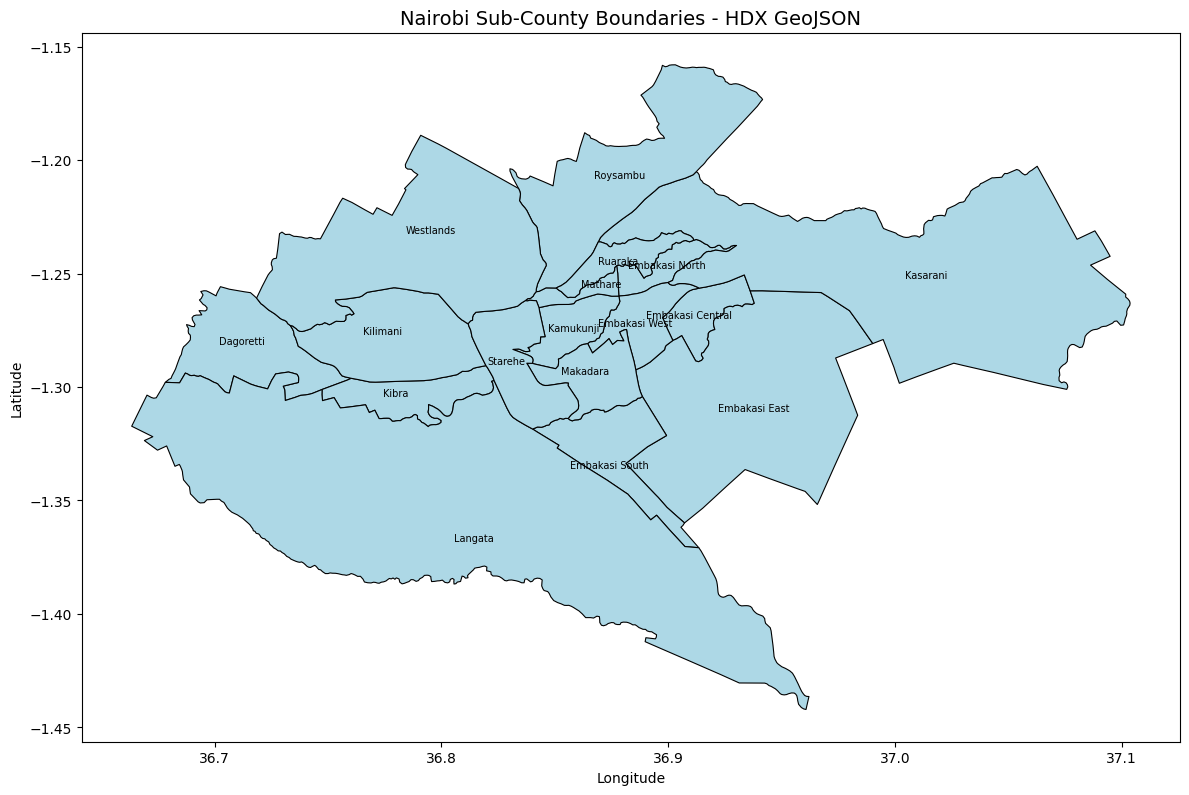

Map saved.


In [13]:
# CELL 12 — VISUALISE GEOJSON BOUNDARIES TO INSPECT VISUALLY

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

nairobi_geo.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.8)

for idx, row in nairobi_geo.iterrows():
    ax.annotate(
        row['adm2_name'],
        xy=(row['center_lon'], row['center_lat']),
        fontsize=7,
        ha='center',
        color='black'
    )

ax.set_title('Nairobi Sub-County Boundaries - HDX GeoJSON', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(r"C:\Users\User\Desktop\Data Analysis\Nairobi Public Health Facility Access Analysis\visuals\nairobi_boundaries_check.png", dpi=150)
plt.show()
print("Map saved.")

In [14]:
# CELL 12 — NAIROBI 17 CONSTITUENCY POPULATION
# Sources: KNBS 2019 Census via Wikipedia constituency articles and Grokipedia
# GeoJSON name corrections: 'Kilimani' = Dagoretti North, 'Dagoretti' = Dagoretti South

nairobi_pop_17 = pd.DataFrame({
    'geo_name': [
        'Westlands', 'Kilimani', 'Dagoretti', 'Langata', 'Kibra',
        'Roysambu', 'Kasarani', 'Ruaraka',
        'Embakasi South', 'Embakasi North', 'Embakasi Central',
        'Embakasi East', 'Embakasi West',
        'Makadara', 'Kamukunji', 'Starehe', 'Mathare'
    ],
    'sub_county': [
        'Westlands', 'Dagoretti North', 'Dagoretti South', 'Langata', 'Kibra',
        'Roysambu', 'Kasarani', 'Ruaraka',
        'Embakasi South', 'Embakasi North', 'Embakasi Central',
        'Embakasi East', 'Embakasi West',
        'Makadara', 'Kamukunji', 'Starehe', 'Mathare'
    ],
    'total_pop': [
        308854, 181365, 178691, 178282, 185777,
        265079, 780656, 192620,
        272519, 181388, 185948,
        272519, 272733,
        218641, 261855, 274607, 206564
    ],
    'area_sqkm': [
        72.40, 29.00, 25.30, 209.81, 12.13,
        48.80, 136.27, 7.18,
        12.00, 5.43, 8.18,
        85.84, 9.76,
        11.74, 10.54, 20.62, 3.00
    ],
    'source': [
        'KNBS 2019/Grokipedia', 'Wikipedia ward sum', 'Wikipedia ward sum',
        'Grokipedia', 'Wikipedia',
        'Grokipedia', 'Wikipedia', 'Wikipedia/Ruaraka CDF',
        'nairobipostalcode.org', 'Tuko.co.ke', 'Tuko.co.ke',
        'nairobipostalcode.org', 'nairobipostalcode.org',
        'Wikipedia', 'Wikipedia', 'Wikipedia', 'KNBS 2019'
    ]
})

nairobi_pop_17['density_per_sqkm'] = (
    nairobi_pop_17['total_pop'] / nairobi_pop_17['area_sqkm']
).round(2)

print("Shape:", nairobi_pop_17.shape)
print("\nTotal population:", nairobi_pop_17['total_pop'].sum())
print("Expected (2019 census):", 4397073)
print("Difference:", 4397073 - nairobi_pop_17['total_pop'].sum())
print("\nFull table:")
print(nairobi_pop_17[['sub_county','total_pop','area_sqkm','density_per_sqkm']].to_string())

Shape: (17, 6)

Total population: 4418098
Expected (2019 census): 4397073
Difference: -21025

Full table:
          sub_county  total_pop  area_sqkm  density_per_sqkm
0          Westlands     308854      72.40           4265.94
1    Dagoretti North     181365      29.00           6253.97
2    Dagoretti South     178691      25.30           7062.89
3            Langata     178282     209.81            849.73
4              Kibra     185777      12.13          15315.50
5           Roysambu     265079      48.80           5431.95
6           Kasarani     780656     136.27           5728.74
7            Ruaraka     192620       7.18          26827.30
8     Embakasi South     272519      12.00          22709.92
9     Embakasi North     181388       5.43          33404.79
10  Embakasi Central     185948       8.18          22732.03
11     Embakasi East     272519      85.84           3174.73
12     Embakasi West     272733       9.76          27943.95
13          Makadara     218641      11.

In [15]:
# CELL 13 — CORRECTIONS

# Fix column name
nairobi_pop_17 = nairobi_pop_17.rename(columns={'sub_county': 'constituency'})

# Fix duplicate — Embakasi East correct figure from Wikipedia ward data
# Upper Savannah + Lower Savannah + Embakasi + Utawala + Mihango
nairobi_pop_17.loc[nairobi_pop_17['constituency'] == 'Embakasi East', 'total_pop'] = 255979

nairobi_pop_17['density_per_sqkm'] = (
    nairobi_pop_17['total_pop'] / nairobi_pop_17['area_sqkm']
).round(2)

total = nairobi_pop_17['total_pop'].sum()
expected = 4397073

print("Total:", total)
print("Expected:", expected)
print("Variance:", total - expected)
print("Variance %:", round(((total - expected) / expected) * 100, 2), "%")
print("\nDuplicate check:")
print(nairobi_pop_17[nairobi_pop_17['total_pop'].duplicated(keep=False)][['constituency','total_pop']])
print("\nFull table:")
print(nairobi_pop_17[['constituency','total_pop','area_sqkm','density_per_sqkm']].to_string())

Total: 4401558
Expected: 4397073
Variance: 4485
Variance %: 0.1 %

Duplicate check:
Empty DataFrame
Columns: [constituency, total_pop]
Index: []

Full table:
        constituency  total_pop  area_sqkm  density_per_sqkm
0          Westlands     308854      72.40           4265.94
1    Dagoretti North     181365      29.00           6253.97
2    Dagoretti South     178691      25.30           7062.89
3            Langata     178282     209.81            849.73
4              Kibra     185777      12.13          15315.50
5           Roysambu     265079      48.80           5431.95
6           Kasarani     780656     136.27           5728.74
7            Ruaraka     192620       7.18          26827.30
8     Embakasi South     272519      12.00          22709.92
9     Embakasi North     181388       5.43          33404.79
10  Embakasi Central     185948       8.18          22732.03
11     Embakasi East     255979      85.84           2982.05
12     Embakasi West     272733       9.76       

In [16]:
# CELL 14 — DOCUMENT DATA LIMITATIONS HONESTLY

print("DATA QUALITY ASSESSMENT")
print("="*50)
print(f"Total: {nairobi_pop_17['total_pop'].sum():,}")
print(f"Expected county total: 4,397,073")
print(f"Variance: {nairobi_pop_17['total_pop'].sum() - 4397073:,}")
print()
print("Confirmed from KNBS directly:")
confirmed = ['Westlands','Kasarani','Kibra','Mathare','Ruaraka',
             'Dagoretti North','Dagoretti South']
print(nairobi_pop_17[nairobi_pop_17['constituency'].isin(confirmed)][['constituency','total_pop']].to_string())
print()
print("Sourced from secondary/mixed sources:")
mixed = nairobi_pop_17[~nairobi_pop_17['constituency'].isin(confirmed)]
print(mixed[['constituency','total_pop','source']].to_string())

DATA QUALITY ASSESSMENT
Total: 4,401,558
Expected county total: 4,397,073
Variance: 4,485

Confirmed from KNBS directly:
       constituency  total_pop
0         Westlands     308854
1   Dagoretti North     181365
2   Dagoretti South     178691
4             Kibra     185777
6          Kasarani     780656
7           Ruaraka     192620
16          Mathare     206564

Sourced from secondary/mixed sources:
        constituency  total_pop                 source
3            Langata     178282             Grokipedia
5           Roysambu     265079             Grokipedia
8     Embakasi South     272519  nairobipostalcode.org
9     Embakasi North     181388             Tuko.co.ke
10  Embakasi Central     185948             Tuko.co.ke
11     Embakasi East     255979  nairobipostalcode.org
12     Embakasi West     272733  nairobipostalcode.org
13          Makadara     218641              Wikipedia
14         Kamukunji     261855              Wikipedia
15           Starehe     274607           

In [17]:
# CELL 15 — ADD SOURCE TRANSPARENCY COLUMNS

source_type = {
    'Westlands'       : ('KNBS 2019 direct',  'high'),
    'Kasarani'        : ('KNBS 2019 direct',  'high'),
    'Kibra'           : ('KNBS 2019 direct',  'high'),
    'Mathare'         : ('KNBS 2019 direct',  'high'),
    'Ruaraka'         : ('KNBS 2019 direct',  'high'),
    'Dagoretti North' : ('Wikipedia ward sum', 'medium'),
    'Dagoretti South' : ('Wikipedia ward sum', 'medium'),
    'Roysambu'        : ('Grokipedia/Wikipedia','medium'),
    'Langata'         : ('Grokipedia',         'medium'),
    'Embakasi North'  : ('Tuko.co.ke',         'low'),
    'Embakasi Central': ('Tuko.co.ke',         'low'),
    'Embakasi East'   : ('Wikipedia ward sum', 'medium'),
    'Embakasi South'  : ('nairobipostalcode',  'low'),
    'Embakasi West'   : ('nairobipostalcode',  'low'),
    'Makadara'        : ('Wikipedia',          'medium'),
    'Kamukunji'       : ('Wikipedia',          'medium'),
    'Starehe'         : ('Wikipedia',          'medium'),
}

nairobi_pop_17['source_type'] = nairobi_pop_17['constituency'].map(
    lambda x: source_type[x][0]
)
nairobi_pop_17['confidence'] = nairobi_pop_17['constituency'].map(
    lambda x: source_type[x][1]
)

print("Source confidence summary:")
print(nairobi_pop_17.groupby('confidence')['constituency'].count())
print("\nFull table with source metadata:")
print(nairobi_pop_17[['constituency','total_pop','source_type','confidence']].to_string())

print("""
METHODOLOGY NOTE:
The 17-constituency population layer is a reconstruction.
The public 2019 KNBS release does not publish a clean 17-constituency table.
KNBS figures are used directly where available (5 constituencies).
Remaining 12 constituencies are sourced from Wikipedia ward aggregations,
Grokipedia, and administrative sites, cross-validated against the KNBS
county total of 4,397,073.
This layer should be treated as estimated/reconciled, not official census data.
""")

Source confidence summary:
confidence
high      5
low       4
medium    8
Name: constituency, dtype: int64

Full table with source metadata:
        constituency  total_pop           source_type confidence
0          Westlands     308854      KNBS 2019 direct       high
1    Dagoretti North     181365    Wikipedia ward sum     medium
2    Dagoretti South     178691    Wikipedia ward sum     medium
3            Langata     178282            Grokipedia     medium
4              Kibra     185777      KNBS 2019 direct       high
5           Roysambu     265079  Grokipedia/Wikipedia     medium
6           Kasarani     780656      KNBS 2019 direct       high
7            Ruaraka     192620      KNBS 2019 direct       high
8     Embakasi South     272519     nairobipostalcode        low
9     Embakasi North     181388            Tuko.co.ke        low
10  Embakasi Central     185948            Tuko.co.ke        low
11     Embakasi East     255979    Wikipedia ward sum     medium
12     Embakas

In [18]:
# CELL 16 — SAVE POPULATION TABLE AND LOAD FACILITIES

import os

processed_path = os.path.join(BASE_PATH, "data", "processed")

# Save locked population table
nairobi_pop_17.to_csv(
    os.path.join(processed_path, "nairobi_constituencies_population.csv"),
    index=False
)
print("Population table saved.")

# Load facilities data
facilities_raw = pd.read_excel(
    os.path.join(RAW_PATH, "kenya-health-facilities-2017_08_02.xlsx")
)

print("\nFacilities data shape:", facilities_raw.shape)
print("\nColumn names:")
for col in facilities_raw.columns:
    print(f"  '{col}'")
print("\nFirst 5 rows:")
print(facilities_raw.head().to_string())

Population table saved.

Facilities data shape: (8932, 22)

Column names:
  'Code'
  'Name'
  'Registration_number'
  'Keph level'
  'Facility type'
  'Owner'
  'Regulatory body'
  'Beds'
  'Cots'
  'County'
  'Constituency'
  'Sub county'
  'Ward'
  'Operation status'
  'Open_whole_day'
  'Open_public_holidays'
  'Open_weekends'
  'Open_late_night'
  'Service_names'
  'Approved'
  'Public visible'
  'Closed'

First 5 rows:
    Code                              Name Registration_number Keph level                             Facility type                                  Owner                              Regulatory body  Beds  Cots    County      Constituency            Sub county          Ward Operation status Open_whole_day Open_public_holidays Open_weekends Open_late_night  Service_names Approved Public visible Closed
0  22998               Kaka Medical Clinic                 NaN    Level 2  Dispensaries and clinic-out patient only  Private Practice - Medical Specialist             

In [19]:
# CELL 17 — FILTER TO NAIROBI AND INSPECT

nairobi_fac = facilities_raw[
    facilities_raw['County'].str.upper() == 'NAIROBI'
].copy().reset_index(drop=True)

print("Nairobi facilities:", len(nairobi_fac))

print("\nOperation status counts:")
print(nairobi_fac['Operation status'].value_counts())

print("\nKeph level counts:")
print(nairobi_fac['Keph level'].value_counts())

print("\nFacility type counts:")
print(nairobi_fac['Facility type'].value_counts())

print("\nConstituency names in facilities data:")
for name in sorted(nairobi_fac['Constituency'].dropna().unique()):
    print(f"  '{name}'")

Nairobi facilities: 783

Operation status counts:
Operation status
Operational    783
Name: count, dtype: int64

Keph level counts:
Keph level
Level 2    608
Level 3    135
Level 4     30
Level 5      4
Level 6      3
Name: count, dtype: int64

Facility type counts:
Facility type
Dispensaries and clinic-out patient only      534
Basic primary health care facility            130
Primary care hospitals                         42
VCT                                            42
Laboratory                                     12
Administrative Offices                         10
Secondary care hospitals                        5
Comprehensive primary health care facility      4
Comprehensive Teaching &Referral                2
Radiology Clinic                                1
Farewell Home                                   1
Name: count, dtype: int64

Constituency names in facilities data:
  'DAGORETTI NORTH'
  'DAGORETTI SOUTH'
  'EMBAKASI CENTRAL'
  'EMBAKASI EAST'
  'EMBAKASI NORTH'
  'EM

In [20]:
# CELL 18 — VERIFY NAME MATCHING BETWEEN FACILITIES AND POPULATION TABLE

fac_constituencies = set(nairobi_fac['Constituency'].str.upper().unique())
pop_constituencies = set(nairobi_pop_17['constituency'].str.upper().unique())

print("In facilities but NOT in population table:")
print(fac_constituencies - pop_constituencies)

print("\nIn population table but NOT in facilities:")
print(pop_constituencies - fac_constituencies)

print("\nMatched constituencies:")
print(sorted(fac_constituencies & pop_constituencies))

# Standardise constituency name to uppercase in both
nairobi_fac['constituency'] = nairobi_fac['Constituency'].str.upper().str.strip()
nairobi_pop_17['constituency_upper'] = nairobi_pop_17['constituency'].str.upper().str.strip()

print("\nName standardisation done.")
print("Facilities constituencies sample:")
print(nairobi_fac['constituency'].value_counts())


In facilities but NOT in population table:
set()

In population table but NOT in facilities:
set()

Matched constituencies:
['DAGORETTI NORTH', 'DAGORETTI SOUTH', 'EMBAKASI CENTRAL', 'EMBAKASI EAST', 'EMBAKASI NORTH', 'EMBAKASI SOUTH', 'EMBAKASI WEST', 'KAMUKUNJI', 'KASARANI', 'KIBRA', 'LANGATA', 'MAKADARA', 'MATHARE', 'ROYSAMBU', 'RUARAKA', 'STAREHE', 'WESTLANDS']

Name standardisation done.
Facilities constituencies sample:
constituency
STAREHE             136
KIBRA                65
ROYSAMBU             61
WESTLANDS            61
LANGATA              60
DAGORETTI SOUTH      48
KASARANI             48
MAKADARA             43
EMBAKASI CENTRAL     41
EMBAKASI EAST        40
KAMUKUNJI            34
DAGORETTI NORTH      28
EMBAKASI WEST        27
EMBAKASI NORTH       26
RUARAKA              26
EMBAKASI SOUTH       24
MATHARE              15
Name: count, dtype: int64


In [21]:
# CELL 19 — BUILD FACILITY COUNTS WITH KEPH WEIGHTS

# Keep only columns we need
fac_clean = nairobi_fac[['constituency', 'Keph level', 'Facility type']].copy()

# Define weights per KEPH level
# Level 2 = dispensary/clinic = weight 1
# Level 3 = health centre = weight 2  
# Level 4 = county hospital = weight 3
# Level 5 = regional referral = weight 4
# Level 6 = national referral = weight 5

keph_weights = {
    'Level 2': 1,
    'Level 3': 2,
    'Level 4': 3,
    'Level 5': 4,
    'Level 6': 5
}

fac_clean['weight'] = fac_clean['Keph level'].map(keph_weights)

print("Null weights (unmapped KEPH levels):")
print(fac_clean[fac_clean['weight'].isna()]['Keph level'].value_counts())

# Facility count per constituency
fac_counts = fac_clean.groupby('constituency').agg(
    total_facilities  = ('Keph level', 'count'),
    weighted_score    = ('weight', 'sum'),
    level_2_count     = ('Keph level', lambda x: (x == 'Level 2').sum()),
    level_3_count     = ('Keph level', lambda x: (x == 'Level 3').sum()),
    level_4_count     = ('Keph level', lambda x: (x == 'Level 4').sum()),
    level_5_count     = ('Keph level', lambda x: (x == 'Level 5').sum()),
    level_6_count     = ('Keph level', lambda x: (x == 'Level 6').sum()),
).reset_index()

print("\nFacility counts per constituency:")
print(fac_counts.to_string())
print("\nTotal facilities check:", fac_counts['total_facilities'].sum())

Null weights (unmapped KEPH levels):
Series([], Name: count, dtype: int64)

Facility counts per constituency:
        constituency  total_facilities  weighted_score  level_2_count  level_3_count  level_4_count  level_5_count  level_6_count
0    DAGORETTI NORTH                28           40.00             21              4              2              0              1
1    DAGORETTI SOUTH                48           65.00             31             17              0              0              0
2   EMBAKASI CENTRAL                41           55.00             27             14              0              0              0
3      EMBAKASI EAST                39           56.00             23             15              1              0              0
4     EMBAKASI NORTH                26           32.00             20              6              0              0              0
5     EMBAKASI SOUTH                24           32.00             16              8              0           

In [22]:
# CELL 20 — TRACK MISSING 3 FACILITIES

print("Original Nairobi facilities:", len(nairobi_fac))
print("After groupby sum:", fac_counts['total_facilities'].sum())
print("Missing:", len(nairobi_fac) - fac_counts['total_facilities'].sum())

# Find rows that didn't make it into fac_clean groupby
missing = nairobi_fac[~nairobi_fac['constituency'].isin(fac_counts['constituency'])]
print("\nFacilities with unmatched constituency:")
print(missing[['Code','Name','Constituency','constituency','Keph level']].to_string())

# Also check for null constituency
print("\nNull constituency in fac_clean:")
print(fac_clean[fac_clean['constituency'].isna()])

# Check null weights
print("\nNull weights in fac_clean:")
print(fac_clean[fac_clean['weight'].isna()])

Original Nairobi facilities: 783
After groupby sum: 780
Missing: 3

Facilities with unmatched constituency:
Empty DataFrame
Columns: [Code, Name, Constituency, constituency, Keph level]
Index: []

Null constituency in fac_clean:
Empty DataFrame
Columns: [constituency, Keph level, Facility type, weight]
Index: []

Null weights in fac_clean:
      constituency Keph level                             Facility type  \
72        MAKADARA        NaN  Dispensaries and clinic-out patient only   
431          KIBRA        NaN                             Farewell Home   
434  EMBAKASI EAST        NaN  Dispensaries and clinic-out patient only   

     weight  
72      NaN  
431     NaN  
434     NaN  


In [23]:
# CELL 21 — HANDLE NULL KEPH LEVEL FACILITIES

# Inspect the 3 facilities fully
null_keph = nairobi_fac[nairobi_fac['Keph level'].isna()]
print("Full details of null KEPH facilities:")
print(null_keph[['Code','Name','Facility type','Owner','constituency','Operation status']].to_string())

# Decision:
# Farewell Home is not a healthcare facility — exclude it
# The 2 dispensaries/clinics with no KEPH level — assign Level 2 (lowest tier)
# This is a documented imputation decision

farewell_codes = null_keph[null_keph['Facility type'] == 'Farewell Home']['Code'].values
dispensary_codes = null_keph[null_keph['Facility type'] != 'Farewell Home']['Code'].values

print(f"\nFarewell Home codes to exclude: {farewell_codes}")
print(f"Dispensary codes to impute as Level 2: {dispensary_codes}")

# Apply fix to fac_clean
fac_clean = fac_clean[~fac_clean.index.isin(
    nairobi_fac[nairobi_fac['Code'].isin(farewell_codes)].index
)]

fac_clean.loc[
    nairobi_fac[nairobi_fac['Code'].isin(dispensary_codes)].index,
    'Keph level'
] = 'Level 2'

fac_clean['weight'] = fac_clean['Keph level'].map(keph_weights)

print("\nNull weights remaining:", fac_clean['weight'].isna().sum())
print("Total facilities after fix:", len(fac_clean))

Full details of null KEPH facilities:
      Code                                        Name                             Facility type                                            Owner   constituency Operation status
72   20886                Getrudes Children's Hospital  Dispensaries and clinic-out patient only              Private Practice - Clinical Officer       MAKADARA      Operational
431  17789  Montezuma Monalisa Funeral Home (Lang'ata)                             Farewell Home          Private Practice - General Practitioner          KIBRA      Operational
434  17723               St Barkita Dispensary Utawala  Dispensaries and clinic-out patient only  Kenya Episcopal Conference-Catholic Secretariat  EMBAKASI EAST      Operational

Farewell Home codes to exclude: [17789]
Dispensary codes to impute as Level 2: [20886 17723]

Null weights remaining: 0
Total facilities after fix: 782


In [24]:
# CELL 22 — REBUILD FACILITY COUNTS WITH CLEAN DATA

fac_counts = fac_clean.groupby('constituency').agg(
    total_facilities  = ('Keph level', 'count'),
    weighted_score    = ('weight', 'sum'),
    level_2_count     = ('Keph level', lambda x: (x == 'Level 2').sum()),
    level_3_count     = ('Keph level', lambda x: (x == 'Level 3').sum()),
    level_4_count     = ('Keph level', lambda x: (x == 'Level 4').sum()),
    level_5_count     = ('Keph level', lambda x: (x == 'Level 5').sum()),
    level_6_count     = ('Keph level', lambda x: (x == 'Level 6').sum()),
).reset_index()

print("Total facilities check:", fac_counts['total_facilities'].sum())
print("Expected: 782")
print("\nFacility counts per constituency:")
print(fac_counts.to_string())

# Save to processed
fac_counts.to_csv(
    os.path.join(processed_path, "nairobi_facility_counts.csv"),
    index=False
)
print("\nFacility counts saved.")

Total facilities check: 782
Expected: 782

Facility counts per constituency:
        constituency  total_facilities  weighted_score  level_2_count  level_3_count  level_4_count  level_5_count  level_6_count
0    DAGORETTI NORTH                28              40             21              4              2              0              1
1    DAGORETTI SOUTH                48              65             31             17              0              0              0
2   EMBAKASI CENTRAL                41              55             27             14              0              0              0
3      EMBAKASI EAST                40              57             24             15              1              0              0
4     EMBAKASI NORTH                26              32             20              6              0              0              0
5     EMBAKASI SOUTH                24              32             16              8              0              0              0
6      EMBAKA

In [25]:
# CELL 23 — MERGE POPULATION AND FACILITY COUNTS

# Merge on uppercase constituency name
master = nairobi_pop_17.merge(
    fac_counts,
    left_on='constituency_upper',
    right_on='constituency',
    how='left'
)

# Drop duplicate constituency column
master = master.drop(columns=['constituency_upper', 'constituency_y'])
master = master.rename(columns={'constituency_x': 'constituency'})

print("Master shape:", master.shape)
print("Null check:")
print(master.isnull().sum())
print("\nMaster table:")
print(master[['constituency','total_pop','area_sqkm',
              'total_facilities','weighted_score','confidence']].to_string())

Master shape: (17, 15)
Null check:
geo_name            0
constituency        0
total_pop           0
area_sqkm           0
source              0
density_per_sqkm    0
source_type         0
confidence          0
total_facilities    0
weighted_score      0
level_2_count       0
level_3_count       0
level_4_count       0
level_5_count       0
level_6_count       0
dtype: int64

Master table:
        constituency  total_pop  area_sqkm  total_facilities  weighted_score confidence
0          Westlands     308854      72.40                61              75       high
1    Dagoretti North     181365      29.00                28              40     medium
2    Dagoretti South     178691      25.30                48              65     medium
3            Langata     178282     209.81                60              82     medium
4              Kibra     185777      12.13                64              93       high
5           Roysambu     265079      48.80                61              68   

In [26]:
# CELL 24 — CALCULATE HAII (HEALTHCARE ACCESS INEQUALITY INDEX)

# Layer 1: Facility density per 10,000 people
master['facility_density'] = (
    master['total_facilities'] / master['total_pop'] * 10000
).round(4)

# Layer 2: Weighted access score per 10,000 people
master['weighted_access_per_10k'] = (
    master['weighted_score'] / master['total_pop'] * 10000
).round(4)

# Layer 3: Population pressure (people per km²) — already calculated
# Layer 4: HAII = population pressure / weighted access score per 10k
# High HAII = more people per unit of weighted healthcare access = worse access
master['HAII'] = (
    master['density_per_sqkm'] / master['weighted_access_per_10k']
).round(4)

# Normalise HAII to 0-100 scale for interpretability
haii_min = master['HAII'].min()
haii_max = master['HAII'].max()
master['HAII_normalised'] = (
    (master['HAII'] - haii_min) / (haii_max - haii_min) * 100
).round(2)

# Rank — 1 = most underserved
master['rank'] = master['HAII_normalised'].rank(ascending=False).astype(int)

# Sort by rank
master = master.sort_values('rank').reset_index(drop=True)

print("HAII Rankings — Most Underserved to Best Served:")
print(master[['rank','constituency','total_pop','total_facilities',
              'HAII_normalised','confidence']].to_string())

# Save master
master.to_csv(
    os.path.join(processed_path, "nairobi_master.csv"),
    index=False
)
print("\nMaster table saved.")

HAII Rankings — Most Underserved to Best Served:
    rank      constituency  total_pop  total_facilities  HAII_normalised confidence
0      1           Mathare     206564                15           100.00       high
1      2     Embakasi West     272733                27            36.55        low
2      3    Embakasi South     272519                24            32.43        low
3      4    Embakasi North     181388                26            31.74        low
4      5           Ruaraka     192620                26            25.41       high
5      6         Kamukunji     261855                34            19.35     medium
6      7          Makadara     218641                43            13.75     medium
7      8          Kasarani     780656                48            13.71       high
8      9  Embakasi Central     185948                41            12.70        low
9     10             Kibra     185777                64             4.87       high
10    11   Dagoretti North 

In [27]:
# CELL 25 — SENSE CHECK HAII AGAINST RAW NUMBERS

print("Sense check — facilities per 10,000 people:")
print(master[['constituency','facility_density',
              'weighted_access_per_10k','HAII_normalised',
              'confidence']].to_string())

print("\nKey flags:")
print("Constituencies with < 2 facilities per 10,000 people:")
print(master[master['facility_density'] < 2][
    ['constituency','facility_density','confidence']
].to_string())

Sense check — facilities per 10,000 people:
        constituency  facility_density  weighted_access_per_10k  HAII_normalised confidence
0            Mathare              0.73                     1.16           100.00       high
1      Embakasi West              0.99                     1.28            36.55        low
2     Embakasi South              0.88                     1.17            32.43        low
3     Embakasi North              1.43                     1.76            31.74        low
4            Ruaraka              1.35                     1.77            25.41       high
5          Kamukunji              1.30                     2.14            19.35     medium
6           Makadara              1.97                     2.24            13.75     medium
7           Kasarani              0.61                     0.69            13.71       high
8   Embakasi Central              2.20                     2.96            12.70        low
9              Kibra              3.

In [28]:
# CELL 26 — DOCUMENT KASARANI ANOMALY AND LOCK ANALYSIS

print("ANALYTICAL FINDING — KASARANI ANOMALY:")
print(f"Kasarani facility density: {master.loc[master['constituency']=='Kasarani','facility_density'].values[0]} per 10,000")
print(f"Mathare facility density:  {master.loc[master['constituency']=='Mathare','facility_density'].values[0]} per 10,000")
print(f"Kasarani HAII rank: {master.loc[master['constituency']=='Kasarani','rank'].values[0]}")
print(f"Mathare HAII rank:  {master.loc[master['constituency']=='Mathare','rank'].values[0]}")
print()
print("NOTE: HAII incorporates population density.")
print("Kasarani's large area (136 km²) reduces density, deflating HAII despite low facility count.")
print("Raw facility density tells a different story — both are severely underserved.")
print()
print("HEADLINE FINDING:")
below_2 = master[master['facility_density'] < 2]
print(f"{len(below_2)} of 17 constituencies below 2 facilities per 10,000 people")
print()
print("Top 5 most underserved by HAII (confirmed high/medium confidence only):")
confirmed = master[master['confidence'].isin(['high','medium'])].head(5)
print(confirmed[['rank','constituency','facility_density','HAII_normalised','confidence']].to_string())

ANALYTICAL FINDING — KASARANI ANOMALY:
Kasarani facility density: 0.6149 per 10,000
Mathare facility density:  0.7262 per 10,000
Kasarani HAII rank: 8
Mathare HAII rank:  1

NOTE: HAII incorporates population density.
Kasarani's large area (136 km²) reduces density, deflating HAII despite low facility count.
Raw facility density tells a different story — both are severely underserved.

HEADLINE FINDING:
11 of 17 constituencies below 2 facilities per 10,000 people

Top 5 most underserved by HAII (confirmed high/medium confidence only):
   rank constituency  facility_density  HAII_normalised confidence
0     1      Mathare              0.73           100.00       high
4     5      Ruaraka              1.35            25.41       high
5     6    Kamukunji              1.30            19.35     medium
6     7     Makadara              1.97            13.75     medium
7     8     Kasarani              0.61            13.71       high
